# Incremental capacity analysis (dQ/dV)
In this notebook we illustrate how to extract dQ/dV data for selected cycles.

Prefer `from cellpy import ica` (`cellpy.utils.ica` is the same module). The
sibling verb `ica.dvdq` does differential voltage analysis (dV/dQ). Short
recipe: [Compute ICA / DVA](../guides/ica.md).

- **`ica.dqdv`**: the dQ/dV entry point. It accepts three kinds of input:
    - a `CellpyCell` object (the usual case),
    - a capacity vs voltage curve frame from `get_cap(categorical_column=True, label_cycle_number=True)`,
    - a cellpy-agnostic `(voltage, capacity)` pair of arrays or Pandas Series.

In all three cases it returns the same tidy frame: `cycle`, `direction`, `voltage`, `capacity`, `dqdv`.

!!! note "Coming from cellpy 1.x / 2.0"

    The separate `ica.dqdv_cycle`, `ica.dqdv_cycles` and `ica.dqdv_np` helpers (and
    `ica.Converter`) were removed in 2.1 — `ica.dqdv` covers all of them via the input
    forms above. The duplicate `dq` output column is gone too; use `dqdv`. See the
    [2.0 → 2.1 migration guide](../getting_started/migration_v2.0_to_2.1.md).


In [1]:
import cellpy
from cellpy import ica
from cellpy.utils import example_data


<div class="alert alert-block alert-info">
<b>Tip:</b> The plots in this notebook are based on <code>plotly</code>. If you have not installed plotly, you can do so by running <code>pip install plotly</code>. Alternatively, you can of course also use standard plotting tools such as <code>matplotlib</code> to plot the data from the obtained pandas DataFrames.</div>

In [2]:
import plotly.express as px

Load an example datafile:

In [3]:
c = example_data.cellpy_file()

## Extracting dQ/dV data using `ica.dqdv`
This example shows how to get dQ/dV data directly and easily from the CellpyCell object (obtained by loading the data using `cellpy.get()`).

The dQ/dV data is provided as a Pandas DataFrame.

Without specifying any further options, the dQ/dV for all cycles contained within the CellpyCell is calculated:

In [4]:
ica_df = ica.dqdv(c)
ica_df.head()

,cycle,direction,voltage,capacity,dqdv
0,1,discharge,0.051583,2310.870568,-6388.687162
1,1,discharge,0.054792,2291.260607,-6828.975477
2,1,discharge,0.058001,2268.134430,-7514.790533
3,1,discharge,0.061210,2242.747378,-8284.857174
4,1,discharge,0.064420,2215.988038,-9098.355196


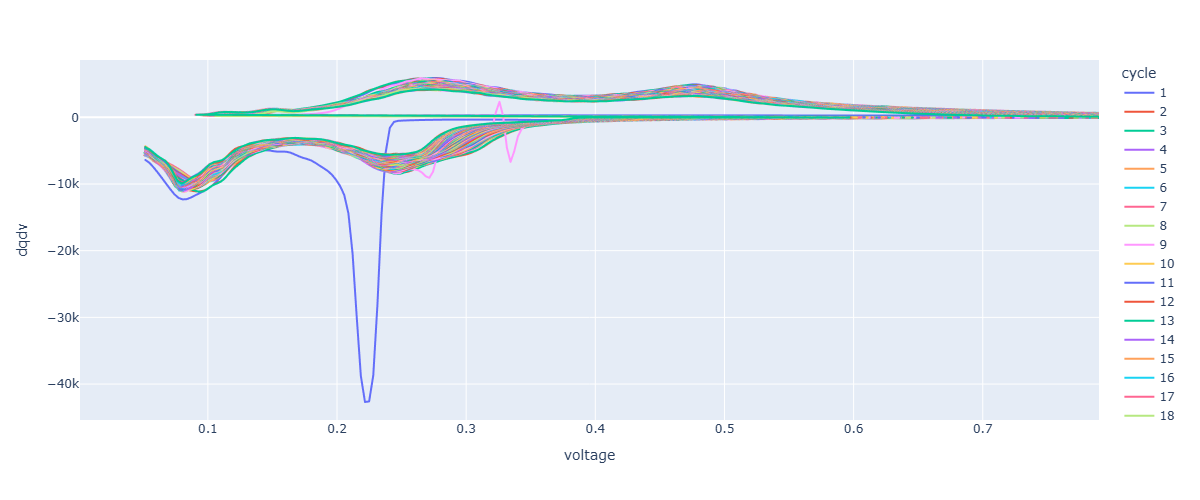

In [5]:
px.line(ica_df, x="voltage", y="dqdv", color="cycle", range_x=[0.001, 0.79])

If cycle number(s) are specified using the `cycles` keyword (as an integer or list of integers), the dQ/dV will be calculated for those cycles only. The result is always one long frame; the `direction` column tells charge and discharge apart, so you split it by filtering (or ask for one direction up front with `direction="charge"`):

In [6]:
cycles = [2, 3, 4]
ica_frame = ica.dqdv(c, cycles=cycles)
charge_ica = ica_frame[ica_frame.direction == "charge"]
discharge_ica = ica_frame[ica_frame.direction == "discharge"]

In [7]:
charge_ica.head(3)

,cycle,direction,voltage,capacity,dqdv
468,2,charge,0.095357,0.357115,323.071717
469,2,charge,0.097555,1.066030,324.656015
470,2,charge,0.099754,1.774946,330.242688


In [8]:
discharge_ica.head(3)

,cycle,direction,voltage,capacity,dqdv
0,2,discharge,0.050879,1987.420359,-5707.834475
1,2,discharge,0.052679,1977.971449,-5816.236742
2,2,discharge,0.054479,1966.295070,-6004.101556


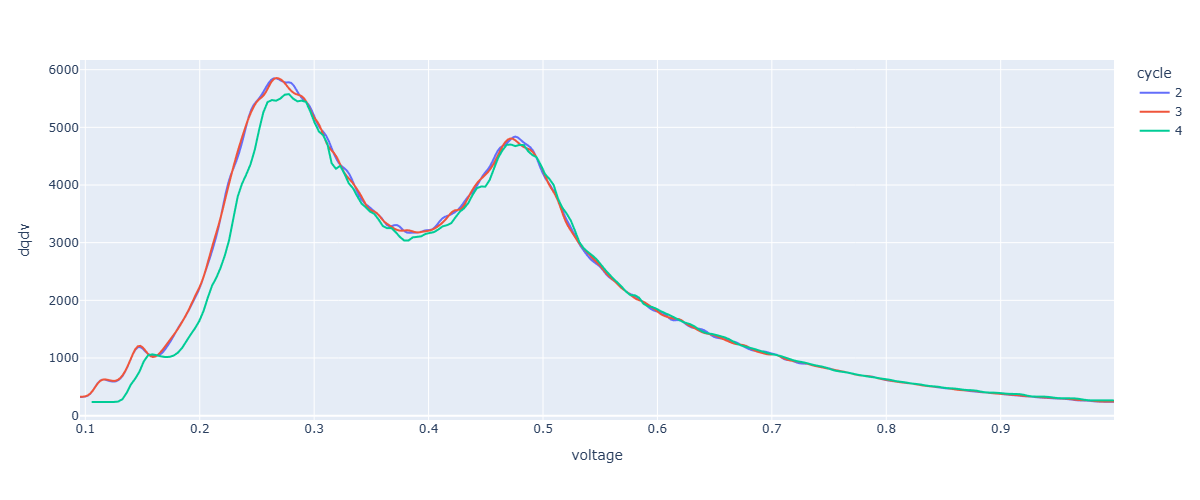

In [9]:
px.line(charge_ica, x="voltage", y="dqdv", color="cycle")

### Tweaking the algorithm

In [10]:
ica_df_1 = ica.dqdv(c, cycles=3, voltage_resolution=0.03)
ica_df_2 = ica.dqdv(c, cycles=3, voltage_resolution=0.01)
ica_df_3 = ica.dqdv(c, cycles=3, voltage_resolution=0.005)

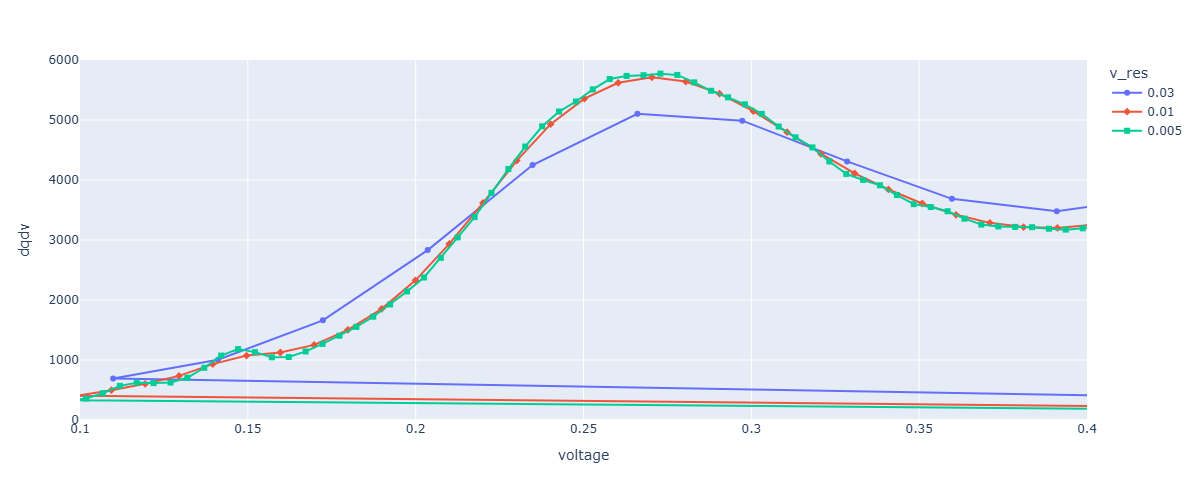

In [11]:
import pandas as pd

ica_both = pd.concat(
    [ica_df_1, ica_df_2, ica_df_3],
    keys=["0.03", "0.01", "0.005"],
    names=["v_res", "index"],
).reset_index()
px.line(
    ica_both,
    x="voltage",
    y="dqdv",
    color="v_res",
    range_x=[0.1, 0.4],
    range_y=[0, 6000],
    symbol="v_res",
)

### More details on dqdv
A lot of different options with respect to smoothing, interpolation etc. are available when calculating the dQ/dV. The signature is

```python
ica.dqdv(source, cycles=None, direction="both", options=None, *,
         strict=False, cycle_mode=None, number_of_points=None, **overrides)
```

where the smoothing and interpolation knobs live on `cellpy.ica.IcaOptions`. Three equivalent ways to use it:

```python
# 1. One-off keyword (as with voltage_resolution= above)
frame = ica.dqdv(c, cycles=3, voltage_resolution=0.005)

# 2. Build a reusable recipe
opts = ica.IcaOptions(
    voltage_resolution=0.005,
    voltage_fwhm=0.015,
    post_smoothing=True,
)
frame = ica.dqdv(c, cycles=3, options=opts)

# 3. Tweak a copy — IcaOptions is frozen, so use replace()
#    Keyword overrides also stack on an existing options object
frame = ica.dqdv(c, cycles=3, options=opts.replace(pre_smoothing=True))
frame = ica.dqdv(c, cycles=3, options=opts, voltage_fwhm=0.02)
```

`dvdq` uses the same class; its default recipe is `ica.DVA_DEFAULTS` (`normalize=False`):

```python
dva = ica.dvdq(c, cycles=3, options=ica.DVA_DEFAULTS.replace(capacity_resolution=5.0))
```

The available fields, with their defaults:

| Field | Default |
|---|---|
| `voltage_resolution` / `capacity_resolution` | `None` (interpolation step) |
| `max_points` | `None` |
| `interpolation_method` | `"linear"` |
| `pre_smoothing` / `diff_smoothing` / `post_smoothing` | `False` / `False` / `True` |
| `savgol_window_divisor` / `savgol_order` | `50` / `3` |
| `voltage_fwhm` / `capacity_fwhm` | `0.01` / `None` (gaussian sigma) |
| `normalize` | `"area"` |
| `normalizing_factor` / `normalizing_roof` | `None` / `None` |
| `increment_method` | `"diff"` |
| `gaussian` | `GaussianOptions(order=0, mode="reflect", cval=0.0, truncate=4.0)` |

Setting `strict=True` raises instead of warning when a half-cycle fails to convert. The returned frame's `.attrs` carries the options used, the resolved cycle mode, and any per-half-cycle failures. See the [ica API reference](../api/ica.md) for the authoritative documentation.

## Using the cellpy-agnostic input forms
Besides a `CellpyCell`, `ica.dqdv` also accepts

- a capacity vs voltage curve frame (for one or several cycles), and
- a plain `(voltage, capacity)` pair of arrays or Pandas Series.

To use these, capacity vs voltage data is needed as input. This has to be extracted first and can be done, e.g., by using the `get_cap` method.

Specify cycle number(s):

In [12]:
cycle = 2
cycles = [2, 3, 4]

Get capacities (note here that `ica.dqdv` requires `categorical_column` and `label_cycle_number` to be set to `True` when it is handed a curve frame). The frame uses the native cellpy-core column names — `cycle_num`, `potential`, `capacity`, `direction`:

In [13]:
vcap = c.get_cap(
    cycle=cycle,
    categorical_column=True,
    method="forth-and-forth",
    insert_nan=False,
    label_cycle_number=True,
)
vcap.head(2)

,cycle_num,potential,capacity,direction
1524,2,0.892503,0.041180,-1
1525,2,0.887276,0.176045,-1


If you only have plain arrays (no cellpy objects at all), hand `ica.dqdv` a `(voltage, capacity)` pair for a single half-cycle:

In [14]:
half = vcap[vcap["direction"] == -1]
ica_from_arrays = ica.dqdv((half["potential"].to_numpy(), half["capacity"].to_numpy()))
ica_from_arrays.head(3)

,cycle,direction,voltage,capacity,dqdv
0,0,charge,0.050879,1987.420359,-5707.834475
1,0,charge,0.052679,1977.971449,-5816.236742
2,0,charge,0.054479,1966.295070,-6004.101556


Handing the curve frame itself to `ica.dqdv` returns the same tidy frame as for a `CellpyCell`:

In [15]:
ica_cycles = ica.dqdv(vcap)
ica_cycles.head()

,cycle,direction,voltage,capacity,dqdv
0,2,discharge,0.050879,1987.420359,-5707.834475
1,2,discharge,0.052679,1977.971449,-5816.236742
2,2,discharge,0.054479,1966.295070,-6004.101556
3,2,discharge,0.056279,1954.789046,-6234.129498
4,2,discharge,0.058080,1943.862902,-6480.747477


Doing the same for multiple cycle numbers:

In [16]:
vcaps = c.get_cap(
    cycle=cycles,
    categorical_column=True,
    method="forth-and-forth",
    insert_nan=False,
    label_cycle_number=True,
)
ica_curves = ica.dqdv(vcaps)

In [17]:
ica_curves.head(2)

,cycle,direction,voltage,capacity,dqdv
0,2,discharge,0.050879,1987.420359,-5707.834475
1,2,discharge,0.052679,1977.971449,-5816.236742


## Differential voltage (dV/dQ) and plotting

`ica.dvdq` is the DVA sibling — same sources and `IcaOptions`, columns
`cycle`, `direction`, `capacity`, `voltage`, `dvdq`. For a figure without
building the frame yourself:

```python
from cellpy.utils.plotutils import ica_plot, dva_plot

fig = ica_plot(c, cycles=[2, 3], voltage_resolution=0.005)
fig = dva_plot(c, cycles=2, direction="charge")
```

Multi-cell: `collect_ica(batch, options=opts, cycles=…)` / `collect_dva(batch, …)`
use the same `IcaOptions` as `dqdv` / `dvdq`. See the
[how-to](../guides/ica.md) and the [API](../api/ica.md).
